
<br>
<font face="Times New Roman">
<div dir=ltr align=center>
<font color=0F5298 size=7>
Digital Image Processing <br>
<font color=2565AE size=5>
Department Of Mathematical Sciences <br>
Spring 2025<br>
<font color=3C99D size=5>
Assignment 3 <br>
</div>


---



### Full Name :Kasra Siavashpour
### Student Number :99109903
___

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

First, read the image:

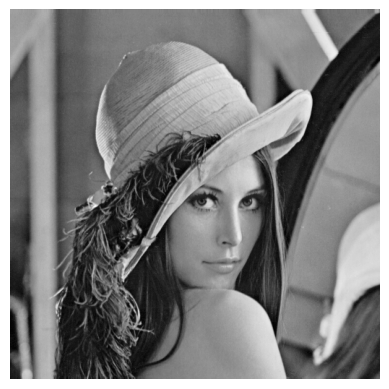

In [2]:
gray = cv2.imread("lena.png", 0)
plt.axis('off')
plt.imshow(gray, cmap="gray")

Complete the sp function below to add random salt and pepper noise to the image with rate n. generate noisy images with rates 0.1, 0.2, 0.3, ... ,1.

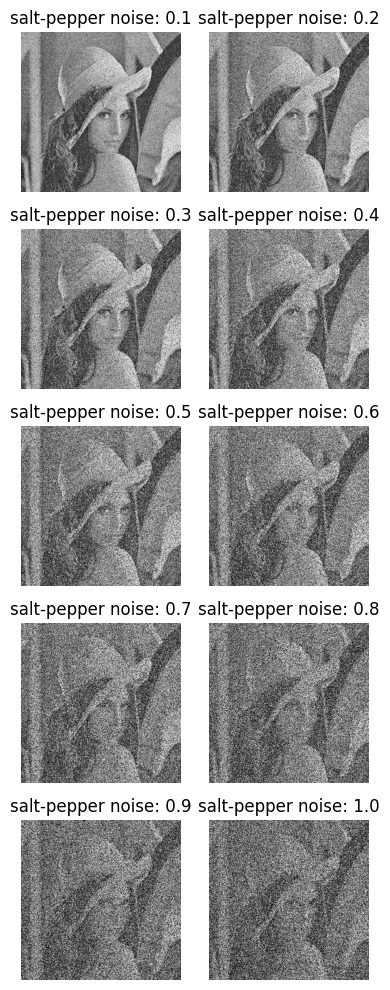

In [3]:
def sp(pic, n):

    ######################## YOUR CODE GOES HERE ########################

    noise_img = pic.copy()
    total_pixels = pic.size
    num_salt = int(np.ceil(n * total_pixels / 2))
    num_pepper = int(np.ceil(n * total_pixels / 2))

    # Salt noise (white pixels)
    coords = [np.random.randint(0, i, num_salt) for i in pic.shape]
    noise_img[coords[0], coords[1]] = 255

    # Pepper noise (black pixels)
    coords = [np.random.randint(0, i, num_pepper) for i in pic.shape]
    noise_img[coords[0], coords[1]] = 0

    ######################### END OF YOUR CODE ##########################

    return noise_img

a = []
for i in range(1, 11):
    a.append(sp(gray, 0.1 * i))

fig, axes = plt.subplots(5, 2, figsize=(4, 10))
axes = axes.flatten()

for idx, (ax, img) in enumerate(zip(axes, a)):
    ax.imshow(img, cmap='gray')
    ax.set_title(f"salt-pepper noise: {np.round((idx + 1) * 0.1, 2)}")
    ax.axis('off')

plt.tight_layout()
plt.show()

Implement a function that takes a noisy image as input and applies a mean filter of size kernel_size * kernel_size on it. Use numpy only.



In [4]:
def apply_mean_filter(image, kernel_size):
    """
    Apply an n x n mean filter to the input image using zero padding.

    Parameters:
        image (np.ndarray): Grayscale image
        kernel_size (int): Size of the mean filter (must be odd)

    Returns:
        np.ndarray: Filtered image of same shape
    """
    ######################## YOUR CODE GOES HERE ########################

    pad = kernel_size // 2
    padded_img = np.pad(image, pad, mode='constant', constant_values=0)
    filtered_image = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded_img[i:i+kernel_size, j:j+kernel_size]
            filtered_image[i, j] = np.mean(region)

    filtered_image = np.clip(filtered_image, 0, 255).astype(np.uint8)

    ######################### END OF YOUR CODE ##########################

    return filtered_image

In [5]:
def display_results(noisy_image, method_function, filter_name):
    pics = [noisy_image]
    titles = ["Original noisy image"]
    kernel_sizes = [3, 5, 7]
    for i, k in enumerate(kernel_sizes):
        filtered_image = method_function(a[0], k)
        pics.append(filtered_image)
        titles.append(f"{filter_name} filter with kernel size {k}")

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.flatten()

    for idx, (ax, img) in enumerate(zip(axes, pics)):
        ax.imshow(img, cmap='gray')
        ax.set_title(titles[idx])
        ax.axis('off')

    plt.tight_layout()
    plt.show()


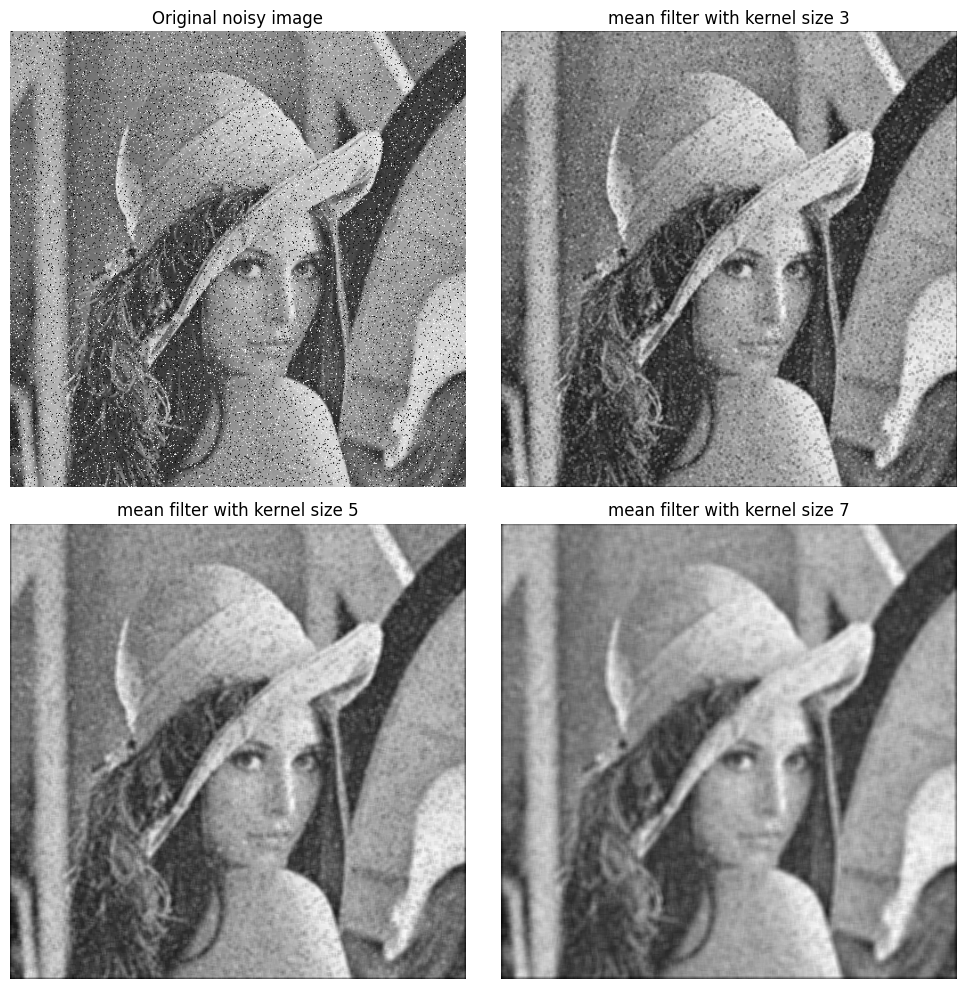

In [6]:
display_results(a[0], apply_mean_filter, filter_name="mean")

###Theory Question:
Explain the reason behind the differences between the outputs of a 3✕3, 5✕5, and 7✕7 mean filter.

###Your Answer: 

The main difference between the outputs of 3✕3, 5✕5, and 7✕7 mean filters is the degree of smoothing applied to the image. A 3✕3 mean filter averages the values of a smaller neighborhood, so it smooths the image slightly and preserves more details. As the kernel size increases to 5✕5 and 7✕7, the filter averages over a larger area, resulting in stronger smoothing. This reduces noise more effectively but also causes more blurring and loss of fine details and edges. In summary, larger mean filters remove more noise but at the cost of greater image blurring.


Use cv2's built-in function(s) to do the same as the mean filter you implemented above.



In [7]:
def builtin_mean_filter(image, kernel_size):
    ######################## YOUR CODE GOES HERE ########################

    filtered_image = cv2.blur(image, (kernel_size, kernel_size))

    ######################### END OF YOUR CODE ##########################
    return filtered_image

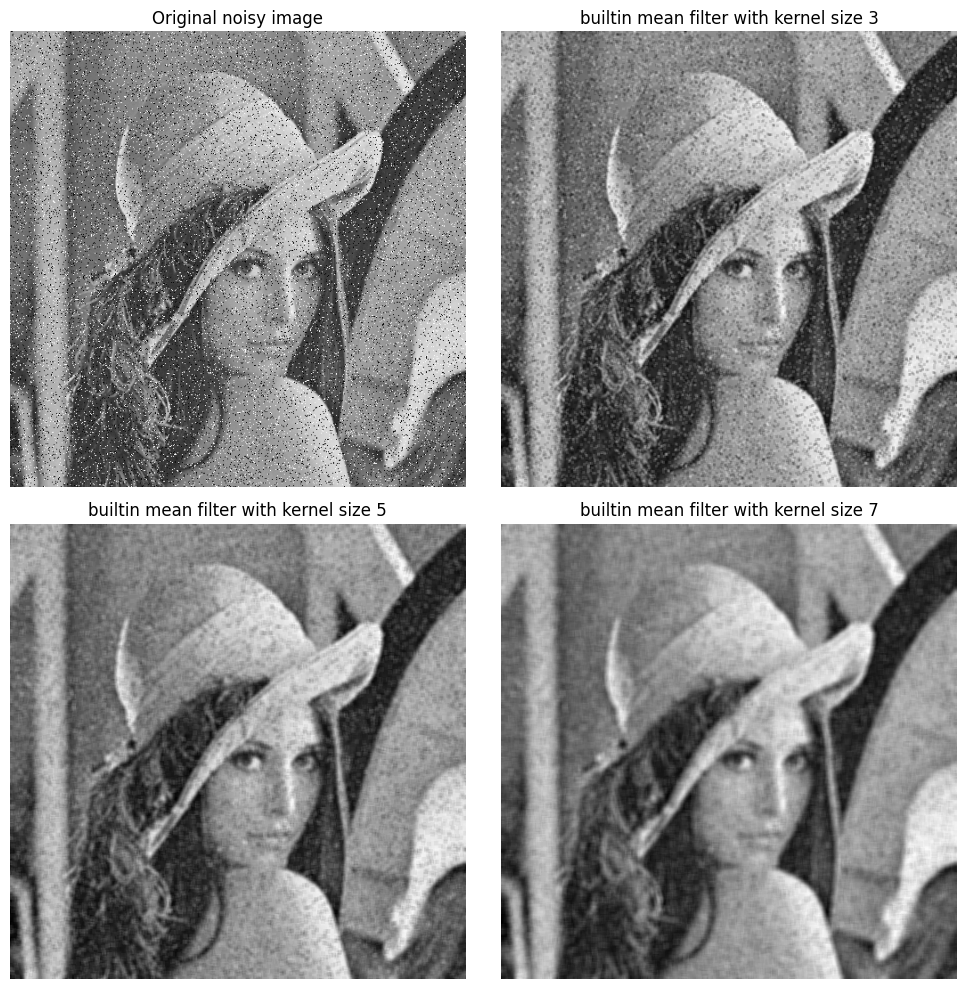

In [8]:
display_results(a[0], builtin_mean_filter, filter_name="builtin mean")

Implement a function that takes a noisy image as input and applies a median filter of size kernel_size * kernel_size on it. Use numpy only.

In [9]:
def apply_median_filter(image, kernel_size):
    """
    Apply an n x n median filter to a grayscale image using zero padding.

    Parameters:
        image (np.ndarray): 2D grayscale image
        kernel_size (int): Size of the filter kernel (must be odd)

    Returns:
        np.ndarray: Filtered image
    """
    ######################## YOUR CODE GOES HERE ########################

    pad = kernel_size // 2
    padded_img = np.pad(image, pad, mode='constant', constant_values=0)
    filtered_image = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded_img[i:i+kernel_size, j:j+kernel_size]
            filtered_image[i, j] = np.median(region)

    filtered_image = np.clip(filtered_image, 0, 255).astype(np.uint8)

    ######################### END OF YOUR CODE ##########################

    return filtered_image

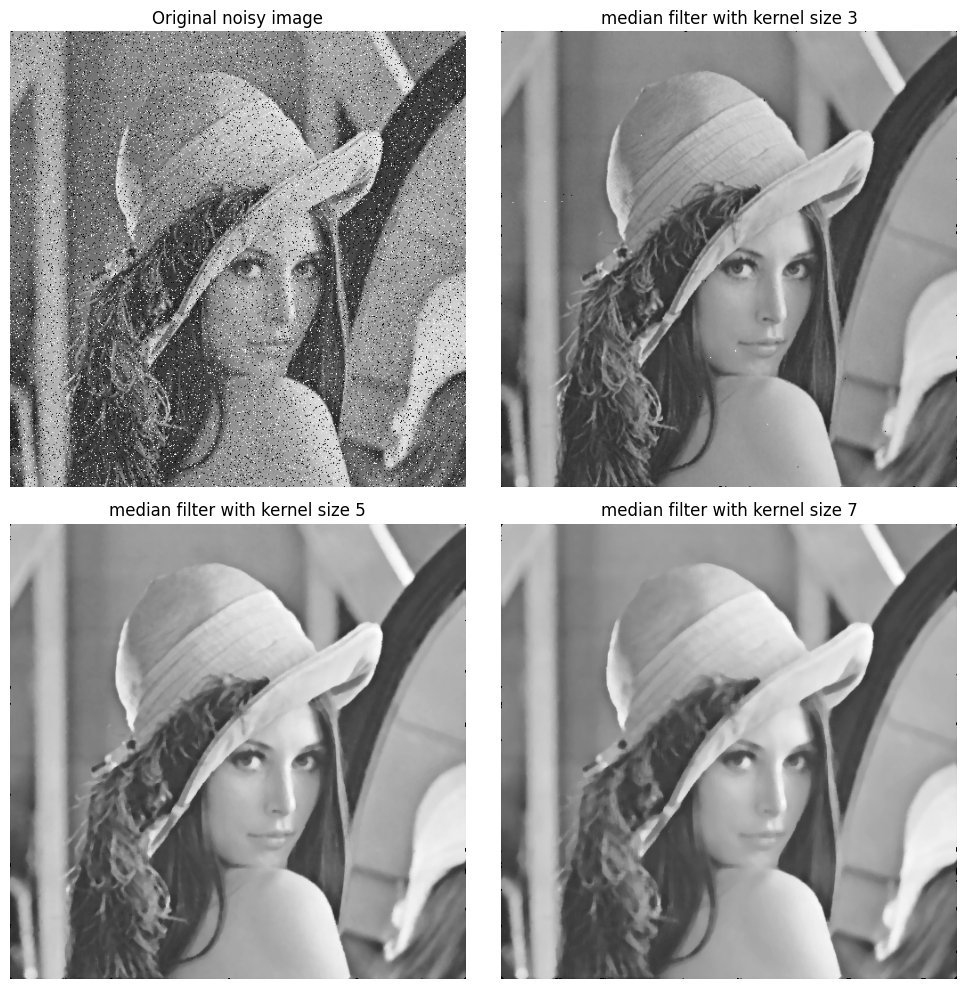

In [10]:
display_results(a[0], apply_median_filter, filter_name="median")

###Theory Question:
Explain the reason behind the differences between the outputs of a 3✕3, 5✕5, and 7✕7 median filter.

###Your Answer:

The main difference between the outputs of 3✕3, 5✕5, and 7✕7 median filters is the amount of noise reduction and detail preservation. A 3✕3 median filter considers a small neighborhood, so it removes isolated noise (like single salt or pepper pixels) while preserving most image details and edges. As the kernel size increases to 5✕5 and 7✕7, the filter considers a larger area, which can remove larger noise patches and more effectively suppress salt and pepper noise. However, larger kernels also cause more blurring and loss of fine details and edges. In summary, increasing the kernel size increases noise removal but also increases the loss of image details.


Use cv2's built-in function(s) to do the same as the median filter you implemented above.

In [11]:
def builtin_median_filter(image, kernel_size):
    ######################## YOUR CODE GOES HERE ########################

    filtered_image = cv2.medianBlur(image, kernel_size)

    ######################### END OF YOUR CODE ##########################
    return filtered_image

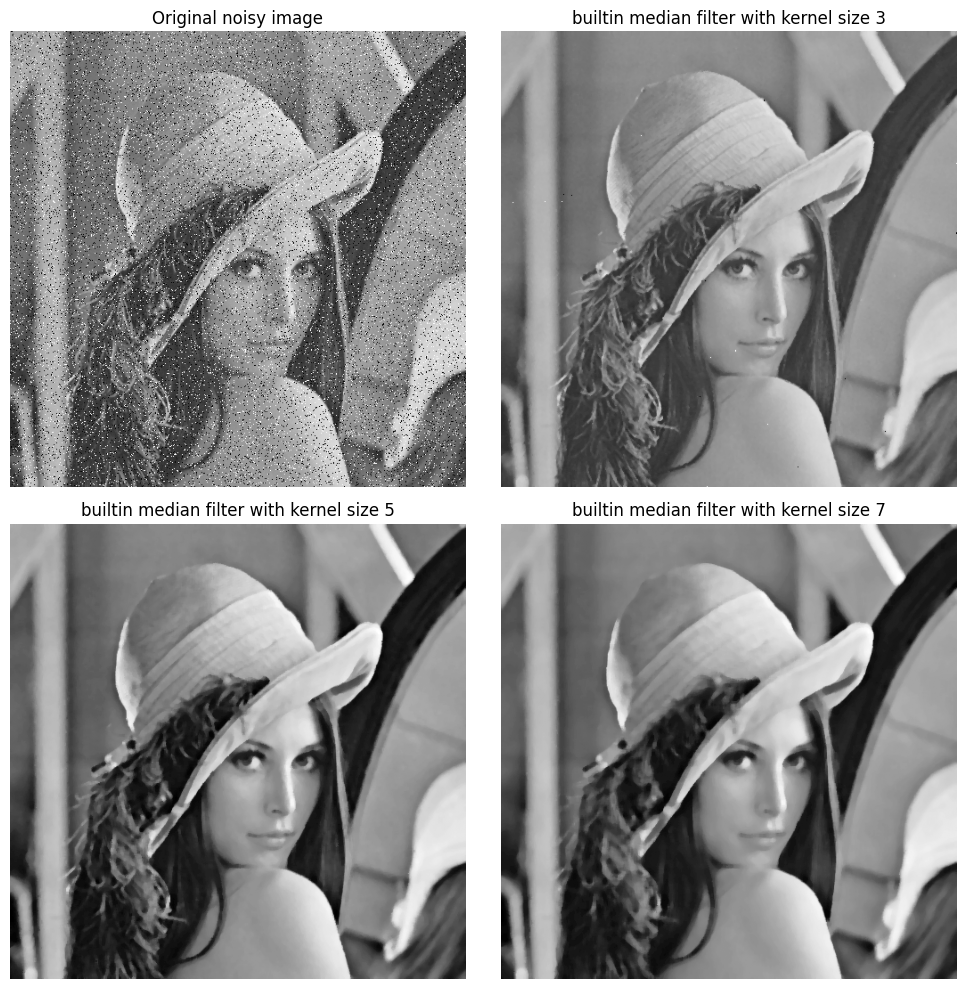

In [12]:
display_results(a[0], builtin_median_filter, filter_name="builtin median")

###Theory Question:
Explain the reason behind the differences between the outputs of a mean and median filter of the same size. Which one performs better on the task of removing salt and pepper noise? why?

###Your Answer:

A mean filter replaces each pixel with the average value of its neighborhood, which smooths the image but can blur edges and is sensitive to outliers like salt and pepper noise. A median filter replaces each pixel with the median value of its neighborhood, which preserves edges better and is much more effective at removing salt and pepper noise because it ignores extreme values. Therefore, the median filter performs better for removing salt and pepper noise, as it can eliminate isolated noisy pixels without significantly blurring the image.